In [1]:
import torch
import numpy as np
from pathlib import Path
from PIL import Image
from IPython.display import display
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

assert torch.cuda.is_available(), "This notebook does not have GPU access."

device = torch.device("cuda")
model_id = "LiheYoung/depth-anything-small-hf"

processor = AutoImageProcessor.from_pretrained(model_id)
model = AutoModelForDepthEstimation.from_pretrained(model_id)
model = model.to(device).eval()

print("Model device:", next(model.parameters()).device)
print("GPU:", torch.cuda.get_device_name(0))

preprocessor_config.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/954 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

Model device: cuda:0
GPU: NVIDIA H100 80GB HBM3 MIG 2g.20gb


Processing: frame000000-1581623790_349.jpg
Image size (width, height): (1920, 1200)
Depth shape (height, width): (1200, 1920)
Raw prediction range: -0.2252451777458191 to 26.157604217529297


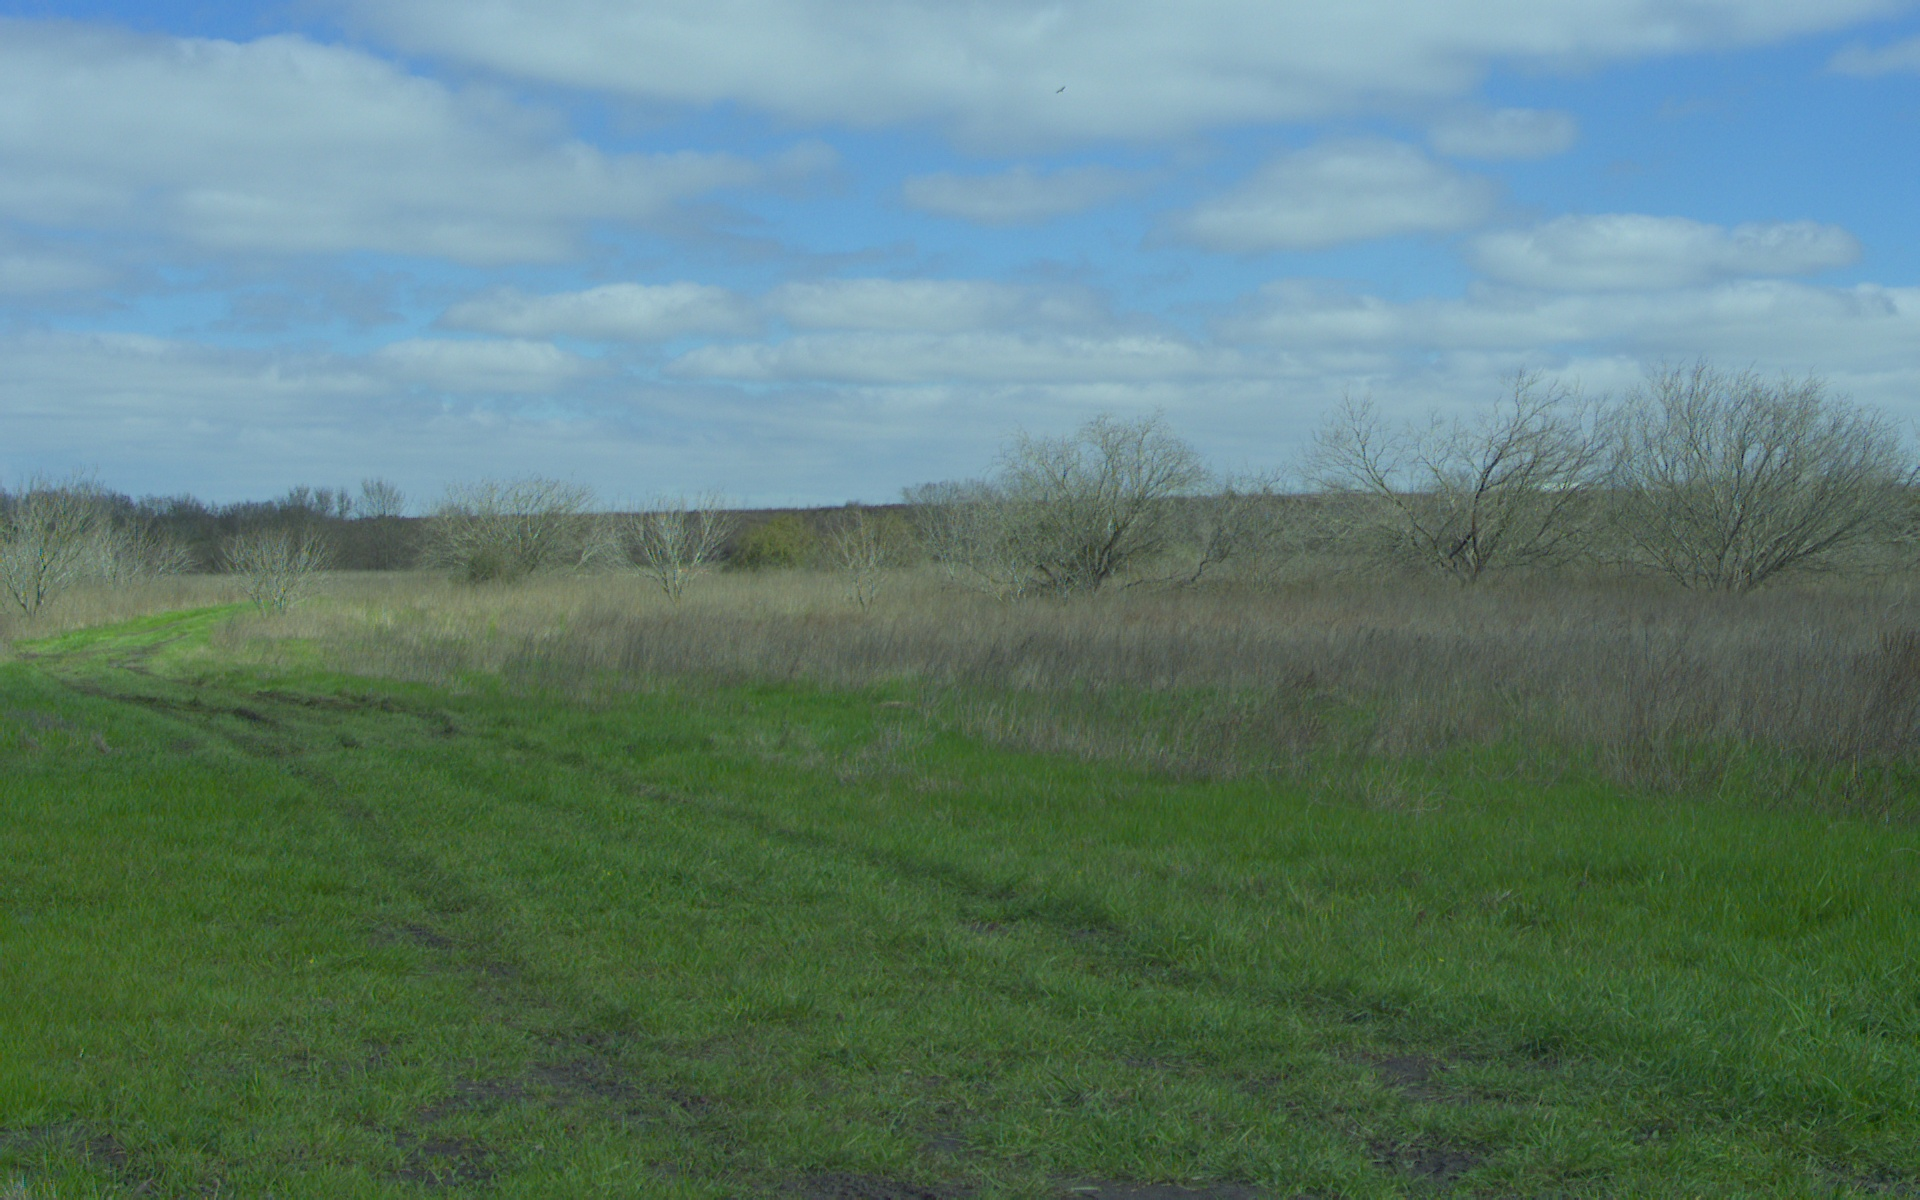

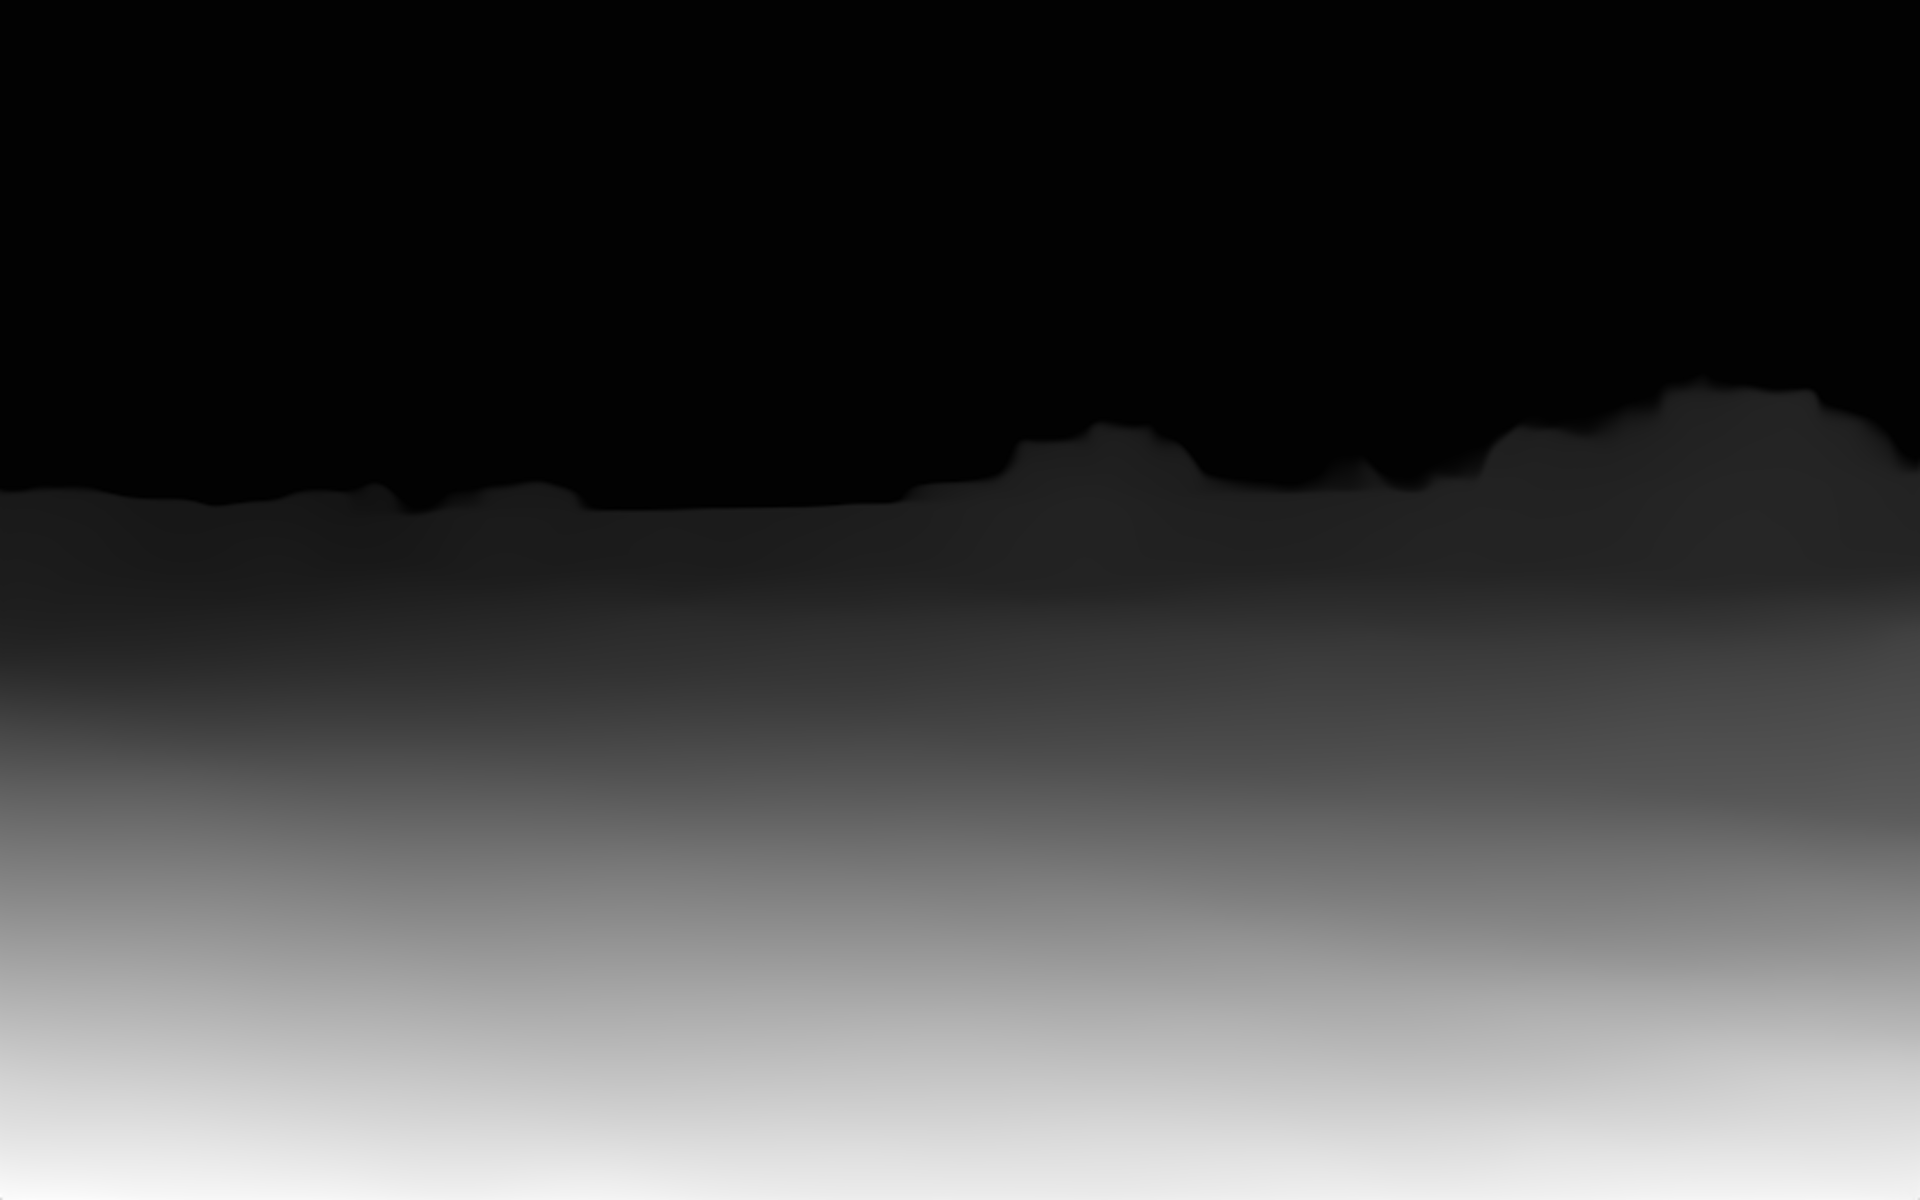

In [17]:
# Load the input image.
image_path = image_paths[0]
image = Image.open(image_path).convert("RGB")
print("Processing:", image_path.name)

# Prepare the image and move its tensor onto the same GPU as the model.
inputs = processor(images=image, return_tensors="pt")
inputs = {name: tensor.to(device) for name, tensor in inputs.items()}

# Predict depth without tracking gradients.
with torch.inference_mode():
    outputs = model(**inputs)

    result = processor.post_process_depth_estimation(
        outputs,
        target_sizes=[(image.height, image.width)],
    )

# Keep the numerical prediction for later geometry calculations.
raw_depth = result[0]["predicted_depth"].float().cpu().numpy()

assert np.isfinite(raw_depth).all(), "Prediction contains invalid values."

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)
np.save(output_dir / f"{image_path.stem}_depth.npy", raw_depth)

# Make a separate grayscale preview.
low, high = float(raw_depth.min()), float(raw_depth.max())
preview_array = (raw_depth - low) / max(high - low, 1e-8)
preview = Image.fromarray((preview_array * 255).astype(np.uint8))
preview.save(output_dir / f"{image_path.stem}_depth_preview.png")

print("Image size (width, height):", image.size)
print("Depth shape (height, width):", raw_depth.shape)
print("Raw prediction range:", low, "to", high)

display(image)
display(preview)

In [18]:
metric_model_id = (
    "depth-anything/Depth-Anything-V2-Metric-Outdoor-Small-hf"
)

metric_processor = AutoImageProcessor.from_pretrained(
    metric_model_id,
    use_fast=False,
)

metric_model = AutoModelForDepthEstimation.from_pretrained(
    metric_model_id
).to(device).eval()

print("Loaded:", metric_model_id)
print("Device:", next(metric_model.parameters()).device)

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

Loaded: depth-anything/Depth-Anything-V2-Metric-Outdoor-Small-hf
Device: cuda:0


Image: frame000000-1581623790_349.jpg
Depth shape: (1200, 1920)
Estimated depth percentiles [1, 50, 99] in metres: [ 6.61 25.51 50.55]


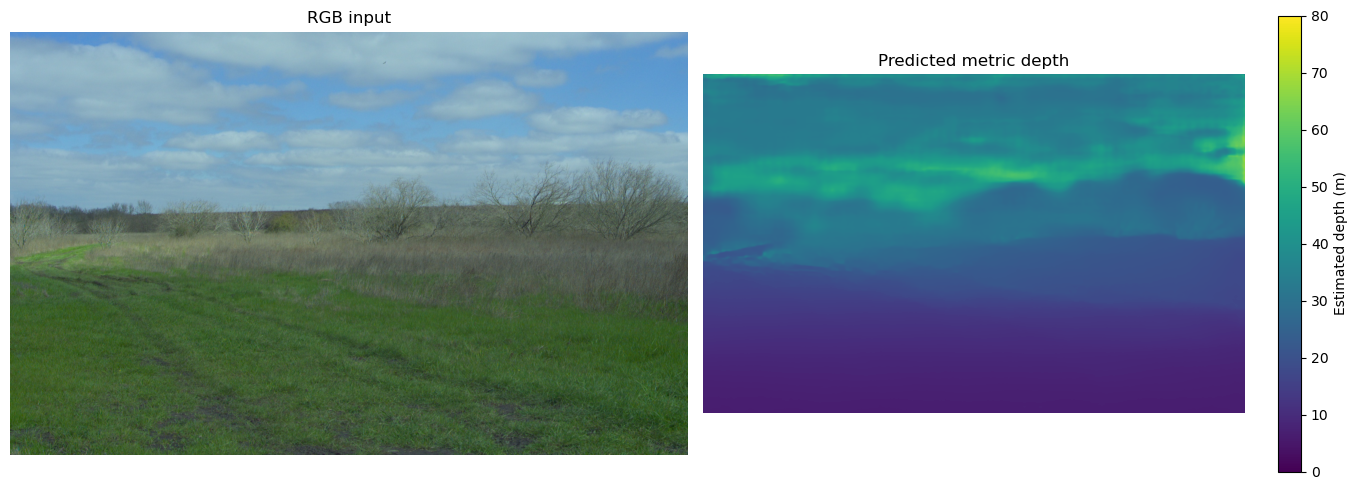

In [19]:
import matplotlib.pyplot as plt

image_path = image_paths[0]
metric_image = Image.open(image_path).convert("RGB")

metric_inputs = metric_processor(
    images=metric_image,
    return_tensors="pt",
)
metric_inputs = {
    name: tensor.to(device)
    for name, tensor in metric_inputs.items()
}

with torch.inference_mode():
    metric_outputs = metric_model(**metric_inputs)

    metric_result = metric_processor.post_process_depth_estimation(
        metric_outputs,
        target_sizes=[(metric_image.height, metric_image.width)],
    )

depth_m = (
    metric_result[0]["predicted_depth"]
    .float()
    .cpu()
    .numpy()
)

assert np.isfinite(depth_m).all(), "Depth contains invalid values."

metric_output_dir = Path("outputs/metric_depth")
metric_output_dir.mkdir(parents=True, exist_ok=True)

np.save(
    metric_output_dir / f"{image_path.stem}_depth_m.npy",
    depth_m,
)

print("Image:", image_path.name)
print("Depth shape:", depth_m.shape)
print(
    "Estimated depth percentiles [1, 50, 99] in metres:",
    np.percentile(depth_m, [1, 50, 99]).round(2),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(metric_image)
axes[0].set_title("RGB input")
axes[0].axis("off")

# Fixed display range for comparing different frames.
plot = axes[1].imshow(
    depth_m,
    cmap="viridis",
    vmin=0,
    vmax=80,
)
axes[1].set_title("Predicted metric depth")
axes[1].axis("off")
fig.colorbar(plot, ax=axes[1], label="Estimated depth (m)")

fig.tight_layout()
plt.show()

Using fx=2813.64, fy=2808.33, cx=969.29, cy=624.05
Reconstructed points: 4320


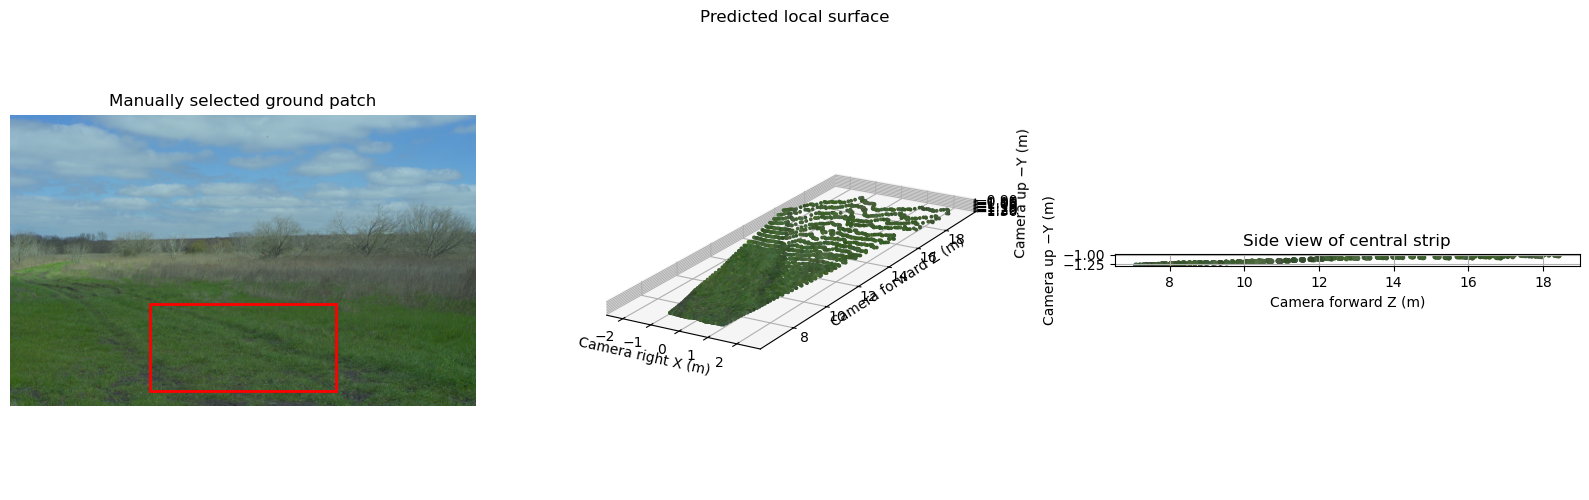

In [20]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# All five calibration files in your download contain identical values.
calib_path = Path(
    "data/rellis_sample/Rellis-3D/00000/camera_info.txt"
)
fx, fy, cx, cy = np.loadtxt(calib_path).reshape(-1)

h, w = depth_m.shape
assert metric_image.size == (w, h), "RGB and depth sizes differ."
assert (w, h) == (1920, 1200), "This cell expects the original RELLIS size."

print(f"Using fx={fx:.2f}, fy={fy:.2f}, cx={cx:.2f}, cy={cy:.2f}")

# Manual diagnostic region: central foreground in the current grass image.
# These coordinates are not an automatic ground detector.
u0, u1 = int(0.30 * w), int(0.70 * w)
v0, v1 = int(0.65 * h), int(0.95 * h)

# Sample every eighth pixel to keep plotting lightweight.
# We retain original pixel coordinates: no intrinsic scaling is needed.
u, v = np.meshgrid(
    np.arange(u0, u1, 8),
    np.arange(v0, v1, 8),
)

Z = depth_m[v, u]
valid = np.isfinite(Z) & (Z > 0)

# Camera coordinates: X right, Y down, Z forward.
X = (u - cx) * Z / fx
Y = (v - cy) * Z / fy

points_camera = np.column_stack([
    X[valid], Y[valid], Z[valid]
])

colors = np.asarray(metric_image)[v, u][valid] / 255.0
X = points_camera[:, 0]
Y = points_camera[:, 1]
Z = points_camera[:, 2]

assert len(Z) > 0, "No valid points in the selected region."
print("Reconstructed points:", len(Z))

fig = plt.figure(figsize=(16, 5))

# 1. Show exactly which image region we selected.
ax1 = fig.add_subplot(131)
ax1.imshow(metric_image)
ax1.add_patch(Rectangle(
    (u0, v0), u1 - u0, v1 - v0,
    fill=False, edgecolor="red", linewidth=2,
))
ax1.set_title("Manually selected ground patch")
ax1.axis("off")

# 2. Plot reconstructed points with their original image colours.
ax2 = fig.add_subplot(132, projection="3d")
ax2.scatter(X, Z, -Y, c=colors, s=3, depthshade=False)
ax2.set_xlabel("Camera right X (m)")
ax2.set_ylabel("Camera forward Z (m)")
ax2.set_zlabel("Camera up −Y (m)")
ax2.set_title("Predicted local surface")
ax2.set_box_aspect([
    max(np.ptp(X), 0.01),
    max(np.ptp(Z), 0.01),
    max(np.ptp(Y), 0.01),
])
ax2.view_init(elev=20, azim=-60)

# 3. A narrow central strip gives a clearer side profile.
centre_strip = np.abs(u[valid] - (u0 + u1) / 2) < 0.025 * w
ax3 = fig.add_subplot(133)
ax3.scatter(
    Z[centre_strip], -Y[centre_strip],
    c=colors[centre_strip], s=8,
)
ax3.set_xlabel("Camera forward Z (m)")
ax3.set_ylabel("Camera up −Y (m)")
ax3.set_title("Side view of central strip")
ax3.set_aspect("equal", adjustable="box")
ax3.grid(True)

fig.tight_layout()
plt.show()

Fitted unit normal [X, Y, Z]: [ 0.0188 -0.9995 -0.0271]
RMS distance to plane: 2.63 cm
95th percentile absolute distance: 5.67 cm


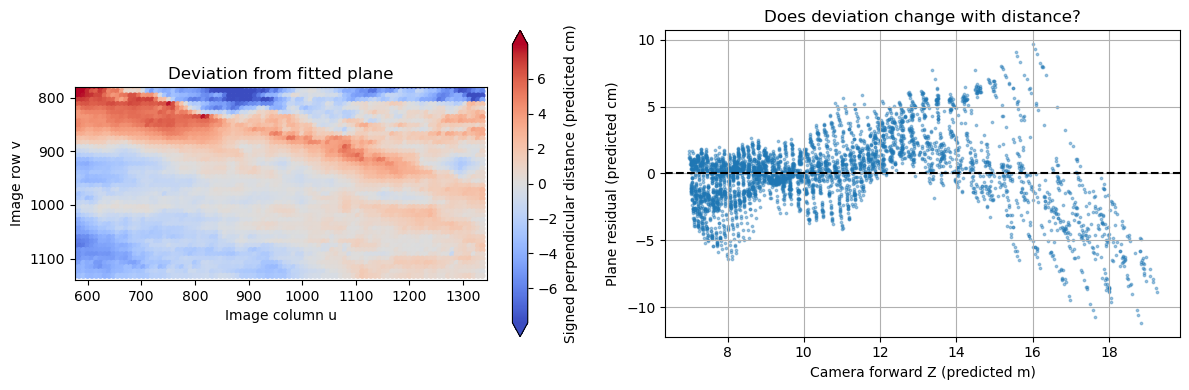

In [21]:
# Fit a plane by minimising squared perpendicular distances.
P = np.asarray(points_camera, dtype=np.float64)
assert len(P) >= 3 and np.isfinite(P).all()

plane_centre = P.mean(axis=0)
centred_points = P - plane_centre

_, singular_values, Vt = np.linalg.svd(
    centred_points,
    full_matrices=False,
)
plane_normal = Vt[-1]

# Orient the normal approximately toward camera-up (negative Y).
if plane_normal[1] > 0:
    plane_normal = -plane_normal

# Signed perpendicular distances, in predicted metres.
residual_m = centred_points @ plane_normal
abs_residual_m = np.abs(residual_m)

print("Fitted unit normal [X, Y, Z]:", plane_normal.round(4))
print(
    "RMS distance to plane:",
    f"{np.sqrt(np.mean(residual_m**2)) * 100:.2f} cm",
)
print(
    "95th percentile absolute distance:",
    f"{np.percentile(abs_residual_m, 95) * 100:.2f} cm",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Show where deviations occur within the selected image patch.
limit_cm = max(np.percentile(abs_residual_m, 99) * 100, 0.1)

plot = axes[0].scatter(
    u[valid], v[valid],
    c=residual_m * 100,
    cmap="coolwarm",
    vmin=-limit_cm,
    vmax=limit_cm,
    s=12,
)
axes[0].set_xlim(u0, u1)
axes[0].set_ylim(v1, v0)
axes[0].set_aspect("equal")
axes[0].set_xlabel("Image column u")
axes[0].set_ylabel("Image row v")
axes[0].set_title("Deviation from fitted plane")
fig.colorbar(
    plot, ax=axes[0],
    label="Signed perpendicular distance (predicted cm)",
    extend="both",
)

axes[1].scatter(P[:, 2], residual_m * 100, s=3, alpha=0.4)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("Camera forward Z (predicted m)")
axes[1].set_ylabel("Plane residual (predicted cm)")
axes[1].set_title("Does deviation change with distance?")
axes[1].grid(True)

fig.tight_layout()
plt.show()